# 05 — Customer Retention Analysis

## Objective

This notebook analyzes customer retention over time using cohort analysis.

The analysis focuses on:

- Grouping customers by their first purchase month
- Tracking whether customers return in subsequent months
- Measuring monthly retention rates
- Comparing retention across Customer Lifetime Value segments
- Identifying opportunities to improve customer retention

The main goal is to understand how effectively the business retains customers after their initial purchase.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

## Load Required Data

This analysis uses completed order records together with the Customer Lifetime Value (CLV) dataset generated in the previous notebook.

The datasets are combined to reconstruct each customer's purchase history, which forms the basis for the cohort retention analysis.

In [2]:
# Load datasets
orders = pd.read_csv(
    "../data/olist_orders_dataset.csv",
    parse_dates=["order_purchase_timestamp"]
)

customers = pd.read_csv(
    "../data/olist_customers_dataset.csv"
)

customer_clv = pd.read_csv(
    "../outputs/customer_clv.csv"
)

In [3]:
orders = orders[
    orders["order_status"] == "delivered"
].copy()

## Build Customer Purchase History

Customer purchase history is constructed by combining completed orders with customer identifiers.

This dataset records when each customer made a purchase and is used to identify acquisition cohorts and measure customer retention over time.

In [4]:
purchase_history = (
    orders.merge(
        customers[
            [
                "customer_id",
                "customer_unique_id"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

purchase_history = purchase_history[
    [
        "customer_unique_id",
        "order_id",
        "order_purchase_timestamp"
    ]
]

purchase_history.head()

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39


In [7]:
print(f"Transactions: {len(purchase_history):,}")
print(f"Unique Customers: {purchase_history['customer_unique_id'].nunique():,}")

Transactions: 96,478
Unique Customers: 93,358


## Assign Customer Cohorts

Customers are grouped into cohorts based on the month of their first completed purchase.

A cohort represents customers who were acquired during the same month. Tracking each cohort over time makes it possible to measure retention patterns and compare how customer engagement changes after acquisition.

In [8]:
# Purchase month for every transaction
purchase_history["Purchase_Month"] = (
    purchase_history["order_purchase_timestamp"]
    .dt.to_period("M")
)

# First purchase month (customer cohort)
purchase_history["Cohort_Month"] = (
    purchase_history
    .groupby("customer_unique_id")["Purchase_Month"]
    .transform("min")
)

purchase_history.head()

,customer_unique_id,order_id,order_purchase_timestamp,Purchase_Month,Cohort_Month
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10,2017-09
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08,2018-08
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-11,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02,2018-02


In [9]:
purchase_year = purchase_history["Purchase_Month"].dt.year
purchase_month = purchase_history["Purchase_Month"].dt.month

cohort_year = purchase_history["Cohort_Month"].dt.year
cohort_month = purchase_history["Cohort_Month"].dt.month

purchase_history["Cohort_Index"] = (
    (purchase_year - cohort_year) * 12
    + (purchase_month - cohort_month)
    + 1
)

purchase_history.head()

,customer_unique_id,order_id,order_purchase_timestamp,Purchase_Month,Cohort_Month,Cohort_Index
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10,2017-09,2
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07,2018-07,1
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08,2018-08,1
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-11,2017-11,1
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02,2018-02,1


The cohort index tells us how many months have passed since a customer's first purchase.

In [10]:
cohort_data = (
    purchase_history
    .groupby(
        ["Cohort_Month", "Cohort_Index"]
    )["customer_unique_id"]
    .nunique()
    .reset_index()
)

cohort_data.head()

,Cohort_Month,Cohort_Index,customer_unique_id
0,2016-09,1,1
1,2016-10,1,262
2,2016-10,7,1
3,2016-10,10,1
4,2016-10,12,1


In [11]:
cohort_counts = cohort_data.pivot(
    index="Cohort_Month",
    columns="Cohort_Index",
    values="customer_unique_id"
)

cohort_counts.head()

Cohort_Index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
Cohort_Month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN


## Calculate Customer Retention Rates

Customer retention is calculated by dividing the number of customers who returned in each subsequent month by the number of customers acquired in the first month of the cohort.

This produces a retention matrix that shows the percentage of customers retained over time for each acquisition cohort.

In [12]:
# Cohort size (Month 1)
cohort_size = cohort_counts.iloc[:, 0]

# Calculate retention rates
retention_matrix = cohort_counts.divide(
    cohort_size,
    axis=0
).round(3)

retention_matrix.head()

Cohort_Index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
Cohort_Month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.004,NaN,NaN,0.004,NaN,0.004,NaN,0.004,NaN,0.004,NaN,0.004,0.008,0.008
2016-12,1.0,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.003,0.003,0.001,0.004,0.001,0.004,0.001,0.001,NaN,0.004,0.001,0.007,0.004,0.001,0.001,0.003,0.004,0.001,NaN
2017-02,1.0,0.002,0.003,0.001,0.004,0.001,0.002,0.002,0.001,0.002,0.001,0.003,0.001,0.002,0.001,0.001,0.001,0.002,NaN,NaN


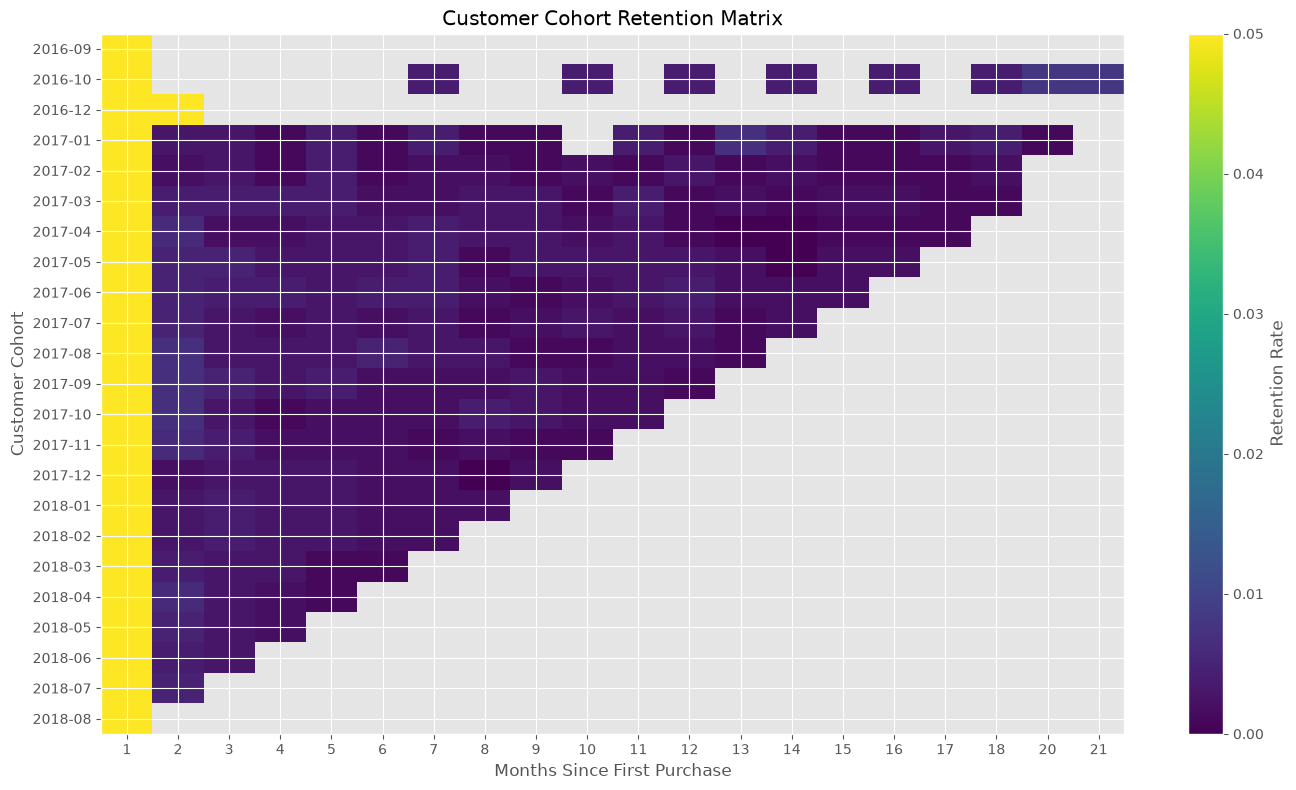

In [15]:
plt.figure(figsize=(14, 8))

plt.imshow(
    retention_matrix,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=0.05      # Scale colors from 0% to 5%
)

plt.colorbar(label="Retention Rate")

plt.title("Customer Cohort Retention Matrix")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer Cohort")

plt.xticks(
    range(len(retention_matrix.columns)),
    retention_matrix.columns
)

plt.yticks(
    range(len(retention_matrix.index)),
    retention_matrix.index.astype(str)
)

plt.tight_layout()
plt.show()

In [14]:
retention_percentage = (
    retention_matrix * 100
).round(1)

retention_percentage.head()

Cohort_Index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
Cohort_Month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.4,NaN,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,0.8,0.8
2016-12,100.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.3,0.3,0.1,0.4,0.1,0.4,0.1,0.1,NaN,0.4,0.1,0.7,0.4,0.1,0.1,0.3,0.4,0.1,NaN
2017-02,100.0,0.2,0.3,0.1,0.4,0.1,0.2,0.2,0.1,0.2,0.1,0.3,0.1,0.2,0.1,0.1,0.1,0.2,NaN,NaN


### Business Insight

The cohort retention analysis shows a sharp decline in customer retention immediately after the acquisition month. While each cohort begins with a retention rate of 100% during its first month, subsequent monthly retention rates remain consistently below 1% for most cohorts.

This indicates that only a very small proportion of customers return to make additional purchases after their first order. The consistency of this pattern across nearly all acquisition cohorts suggests that low customer retention is a persistent characteristic of the business rather than an issue affecting only specific periods.

Improving customer retention through loyalty programs, personalized marketing, and post-purchase engagement represents a significant opportunity for increasing long-term customer value.

## Customer Retention by CLV Segment

To understand how customer value relates to retention, the customer purchase history is combined with the Customer Lifetime Value (CLV) dataset.

This analysis compares retention rates across different CLV segments to determine whether high-value customers are more likely to return than lower-value customers.

In [16]:
# Keep only the columns we need
clv_segments = customer_clv[
    [
        "customer_unique_id",
        "CLV_Segment"
    ]
]

# Merge with purchase history
purchase_clv = purchase_history.merge(
    clv_segments,
    on="customer_unique_id",
    how="left"
)

purchase_clv.head()

,customer_unique_id,order_id,order_purchase_timestamp,Purchase_Month,Cohort_Month,Cohort_Index,CLV_Segment
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10,2017-09,2,Medium
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07,2018-07,1,High
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08,2018-08,1,VIP
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-11,2017-11,1,Low
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02,2018-02,1,Low


In [17]:
# Count purchases per customer
customer_orders = (
    purchase_clv
    .groupby("customer_unique_id")
    .agg(
        Total_Orders=("order_id", "nunique"),
        CLV_Segment=("CLV_Segment", "first")
    )
    .reset_index()
)

# Retention flag
customer_orders["Retained"] = (
    customer_orders["Total_Orders"] > 1
)

customer_orders.head()

,customer_unique_id,Total_Orders,CLV_Segment,Retained
0,0000366f3b9a7992bf8c76cfdf3221e2,1,High,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,Low,False
2,0000f46a3911fa3c0805444483337064,1,Medium,False
3,0000f6ccb0745a6a4b88665a16c9f078,1,Low,False
4,0004aac84e0df4da2b147fca70cf8255,1,VIP,False


In [18]:
retention_clv = (
    customer_orders
    .groupby("CLV_Segment", observed=True)
    .agg(
        Customers=("customer_unique_id", "count"),
        Retained_Customers=("Retained", "sum")
    )
    .reset_index()
)

retention_clv["Retention_Rate (%)"] = (
    retention_clv["Retained_Customers"]
    / retention_clv["Customers"]
    * 100
).round(2)

retention_clv

,CLV_Segment,Customers,Retained_Customers,Retention_Rate (%)
0,High,23339,664,2.85
1,Low,23341,101,0.43
2,Medium,23338,357,1.53
3,VIP,23340,1679,7.19


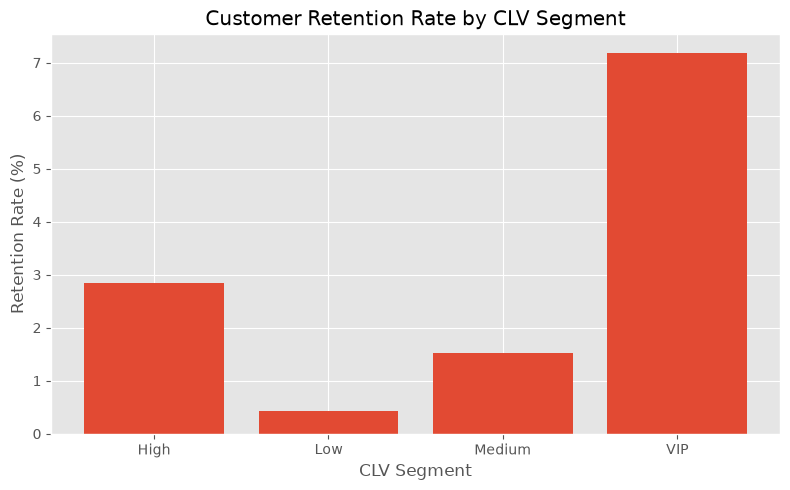

In [19]:
plt.figure(figsize=(8,5))

plt.bar(
    retention_clv["CLV_Segment"],
    retention_clv["Retention_Rate (%)"]
)

plt.title("Customer Retention Rate by CLV Segment")
plt.xlabel("CLV Segment")
plt.ylabel("Retention Rate (%)")

plt.tight_layout()
plt.show()

### Business Insight

Customer retention varies considerably across Customer Lifetime Value (CLV) segments.

The **VIP** segment has the highest retention rate at **7.19%**, followed by the **High** (2.85%), **Medium** (1.53%), and **Low** (0.43%) segments. This indicates a clear positive relationship between customer value and the likelihood of making repeat purchases.

Although overall retention remains low, high-value customers are substantially more likely to return than lower-value customers. This suggests that investing in the retention of VIP and High CLV customers is likely to generate greater long-term returns than applying uniform retention strategies across the entire customer base.

For lower-value customers, businesses should focus on encouraging a second purchase through onboarding campaigns, personalized recommendations, and targeted incentives, as converting first-time buyers into repeat customers can significantly increase their lifetime value.

## Save Outputs

The customer retention analysis is saved for future use in subsequent notebooks and dashboard development.

In [20]:
retention_clv.to_csv(
    "../outputs/retention_analysis.csv",
    index=False
)

print("Retention analysis saved successfully.")

Retention analysis saved successfully.


# Conclusion

This notebook examined customer retention using cohort analysis and Customer Lifetime Value (CLV) segmentation to understand how customer engagement evolves after the first purchase.

### Key Findings

- Cohort analysis revealed a sharp decline in customer retention immediately after acquisition, with most cohorts retaining fewer than 1% of customers in subsequent months.
- The low retention pattern was consistent across nearly all acquisition cohorts, indicating that repeat purchasing is a persistent challenge rather than a short-term issue.
- Retention rates increased with Customer Lifetime Value. VIP customers achieved the highest retention rate (7.19%), while Low CLV customers recorded the lowest (0.43%), demonstrating a strong relationship between customer value and customer loyalty.
- These findings suggest that retaining existing high-value customers while encouraging first-time buyers to make a second purchase represents the greatest opportunity for improving long-term business performance.

### Business Value

The retention analysis highlights customer retention as a key area for business improvement. Combining cohort analysis with CLV segmentation enables organizations to identify valuable customer groups, prioritize retention initiatives, and allocate marketing resources more effectively.

The saved retention analysis will support future predictive modeling and business intelligence applications developed in the remaining notebooks.